<a href="https://colab.research.google.com/github/yelenana/machine_learning/blob/main/%22Rybchynska_Olena_HW_2_4_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%B1%D1%83%D1%81%D1%82%D0%B8%D0%BD%D0%B3%D1%83_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [158]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [159]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [160]:
!ls drive/MyDrive/ML/2_3/

Churn_Modelling.csv    __pycache__	      submission_log_reg.csv  train.csv
process_bank_churn.py  sample_submission.csv  test.csv


In [161]:
import pandas as pd
raw_df = pd.read_csv("drive/MyDrive/ML/2_3/Churn_Modelling.csv")
raw_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [162]:
train_df, val_df = split_train_val(raw_df, "Exited")

In [163]:
train_inputs.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
2151,0.806,0.527027,0.7,0.000000,0.000000,1.0,0.0,0.797394,1.0,0.0,0.0,0.0,1.0
8392,0.778,0.189189,0.3,0.428413,0.000000,1.0,0.0,0.319879,0.0,1.0,0.0,0.0,1.0
5006,0.810,0.256757,0.0,0.477648,0.333333,1.0,1.0,0.586979,0.0,1.0,0.0,1.0,0.0
4117,0.422,0.256757,0.5,0.000000,0.333333,1.0,0.0,0.415448,1.0,0.0,0.0,0.0,1.0
7182,0.684,0.418919,0.6,0.463700,0.333333,0.0,1.0,0.537358,0.0,1.0,0.0,0.0,1.0


In [164]:
val_inputs.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
5702,0.470,0.243243,0.7,0.000000,0.333333,1.0,0.0,0.471403,1.0,0.0,0.0,0.0,1.0
3667,0.350,0.202703,0.4,0.549625,0.333333,0.0,0.0,0.275333,0.0,1.0,0.0,0.0,1.0
1617,0.414,0.297297,0.4,0.000000,0.333333,0.0,1.0,0.527160,0.0,0.0,1.0,1.0,0.0
5673,0.578,0.216216,0.5,0.584733,0.333333,0.0,0.0,0.169709,0.0,0.0,1.0,0.0,1.0
4272,0.580,0.216216,0.3,0.326472,0.000000,1.0,1.0,0.842747,0.0,0.0,1.0,1.0,0.0


In [165]:
input_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
target_col = 'Exited'

train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, target_col)

In [166]:
train_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 2151 to 6206
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      8000 non-null   int64  
 1   Geography        8000 non-null   object 
 2   Gender           8000 non-null   object 
 3   Age              8000 non-null   int64  
 4   Tenure           8000 non-null   int64  
 5   Balance          8000 non-null   float64
 6   NumOfProducts    8000 non-null   int64  
 7   HasCrCard        8000 non-null   int64  
 8   IsActiveMember   8000 non-null   int64  
 9   EstimatedSalary  8000 non-null   float64
dtypes: float64(2), int64(6), object(2)
memory usage: 687.5+ KB


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [167]:
cat_cols = train_df.select_dtypes(include='object').columns

train_df[cat_cols] = train_df[cat_cols].astype('category')
val_df[cat_cols] = val_df[cat_cols].astype('category')

train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, target_col)

In [168]:
train_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 2151 to 6206
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      8000 non-null   int64   
 1   Geography        8000 non-null   category
 2   Gender           8000 non-null   category
 3   Age              8000 non-null   int64   
 4   Tenure           8000 non-null   int64   
 5   Balance          8000 non-null   float64 
 6   NumOfProducts    8000 non-null   int64   
 7   HasCrCard        8000 non-null   int64   
 8   IsActiveMember   8000 non-null   int64   
 9   EstimatedSalary  8000 non-null   float64 
dtypes: category(2), float64(2), int64(6)
memory usage: 578.4 KB


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [169]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

In [170]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True,
    eval_metric='auc'
)


In [171]:
model.fit(train_inputs, train_targets)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [172]:

train_preds_xgb = model.predict_proba(train_inputs)[:, 1]
val_preds_xgb = model.predict_proba(val_inputs)[:, 1]

train_auc_xgb = roc_auc_score(train_targets, train_preds_xgb)
val_auc_xgb = roc_auc_score(val_targets, val_preds_xgb)

print("Train AUROC:", train_auc_xgb)
print("Validation AUROC:", val_auc_xgb)
print("Gap:", train_auc_xgb - val_auc_xgb)

Train AUROC: 0.9307510281129914
Validation AUROC: 0.8642155252324745
Gap: 0.0665355028805169


3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [173]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

In [174]:
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 300, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

In [175]:
def objective(params):
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    clf = XGBClassifier(
        **params,
        enable_categorical=True,
        eval_metric='auc',
        random_state=42
    )

    clf.fit(train_inputs, train_targets)

    preds = clf.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, preds)

    return {'loss': -auc, 'status': STATUS_OK}

In [176]:
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=None
)

100%|██████████| 20/20 [00:05<00:00,  3.79trial/s, best loss: -0.8671753417516128]


In [177]:
best_params = {
    'n_estimators': int(best['n_estimators']),
    'learning_rate': best['learning_rate'],
    'max_depth': int(best['max_depth']),
    'min_child_weight': int(best['min_child_weight']),
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
    'gamma': best['gamma'],
    'reg_alpha': best['reg_alpha'],
    'reg_lambda': best['reg_lambda']
}

In [178]:
final_clf = XGBClassifier(
    **best_params,
    enable_categorical=True,
    eval_metric='auc',
    random_state=42
)

final_clf.fit(train_inputs, train_targets)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.7960554083781652), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=np.float64(0.28796688059191217), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.11844501205886361), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [179]:
train_preds_xgb_tuned = final_clf.predict_proba(train_inputs)[:, 1]
val_preds_xgb_tuned = final_clf.predict_proba(val_inputs)[:, 1]

train_auc_xgb_tuned = roc_auc_score(train_targets, train_preds_xgb_tuned)
val_auc_xgb_tuned = roc_auc_score(val_targets, val_preds_xgb_tuned)

print("Final Train AUROC:", train_auc_xgb_tuned)
print("Final Validation AUROC:", val_auc_xgb_tuned)
print("Gap:", train_auc_xgb_tuned - val_auc_xgb_tuned)
print("Best params:", best_params)

Final Train AUROC: 0.8997603316928471
Final Validation AUROC: 0.8671753417516128
Gap: 0.032584989941234266
Best params: {'n_estimators': 150, 'learning_rate': np.float64(0.11844501205886361), 'max_depth': 3, 'min_child_weight': 2, 'subsample': np.float64(0.8620840250071884), 'colsample_bytree': np.float64(0.7960554083781652), 'gamma': np.float64(0.28796688059191217), 'reg_alpha': np.float64(0.5619667400105333), 'reg_lambda': np.float64(0.22812468208113523)}


Висновок:

Після підбору гіперпараметрів модель XGBoost показала покращення якості. Значення AUROC на валідаційній вибірці зросло з 0.8642 до 0.8684, що свідчить про невелике, але позитивне покращення здатності моделі розрізняти класи.

Крім того, розрив між результатами на тренувальній та валідаційній вибірках зменшився з 0.0665 до 0.0323, що означає зниження перенавчання (overfitting) та кращу здатність моделі до узагальнення.

Отже, оптимізація гіперпараметрів була успішною: модель стала більш стабільною та краще працює на нових даних, демонструючи кращий баланс між bias і variance.



---



4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [180]:
cat_cols = train_inputs.select_dtypes(include='category').columns
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_cols]

print(cat_cols)
print(cat_feature_indexes)

Index(['Geography', 'Gender'], dtype='object')
[1, 2]


In [181]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

In [182]:
lgb_clf = LGBMClassifier(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)


In [183]:
lgb_clf.fit(
    train_inputs,
    train_targets,
    categorical_feature=cat_feature_indexes
)

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 858
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

LGBMClassifier(max_depth=3, random_state=42)

In [184]:
train_preds_lgbm = lgb_clf.predict_proba(train_inputs)[:, 1]
val_preds_lgbm = lgb_clf.predict_proba(val_inputs)[:, 1]

train_auc_lgbm = roc_auc_score(train_targets, train_preds_lgbm)
val_auc_lgbm = roc_auc_score(val_targets, val_preds_lgbm)

print("LightGBM Train AUROC:", train_auc_lgbm)
print("LightGBM Validation AUROC:", val_auc_lgbm)
print("LightGBM Gap:", train_auc_lgbm - val_auc_lgbm)

LightGBM Train AUROC: 0.8854168793520241
LightGBM Validation AUROC: 0.8696176916515899
LightGBM Gap: 0.015799187700434203


5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [185]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

In [186]:
space_lgb = {
    'n_estimators': hp.quniform('n_estimators_lgb', 50, 300, 25),
    'learning_rate': hp.uniform('learning_rate_lgb', 0.01, 0.2),
    'max_depth': hp.quniform('max_depth_lgb', 3, 8, 1),
    'num_leaves': hp.quniform('num_leaves_lgb', 20, 50, 1),
    'min_child_samples': hp.quniform('min_child_samples_lgb', 10, 100, 5),
    'subsample': hp.uniform('subsample_lgb', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree_lgb', 0.6, 1.0),
    'reg_alpha': hp.uniform('reg_alpha_lgb', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda_lgb', 0, 1)
}

In [187]:
def objective_lgb(params):
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['num_leaves'] = int(params['num_leaves'])
    params['min_child_samples'] = int(params['min_child_samples'])

    lgb_clf_tuned = LGBMClassifier(
        **params,
        missing=np.nan,
        random_state=42
    )

    lgb_clf_tuned.fit(
        train_inputs,
        train_targets,
        categorical_feature=cat_feature_indexes
    )

    val_preds_lgb_tuned = lgb_clf_tuned.predict_proba(val_inputs)[:, 1]
    val_auc_lgb_tuned = roc_auc_score(val_targets, val_preds_lgb_tuned)

    return {'loss': -val_auc_lgb_tuned, 'status': STATUS_OK}

In [188]:
trials_lgb = Trials()

best_lgb = fmin(
    fn=objective_lgb,
    space=space_lgb,
    algo=tpe.suggest,
    max_evals=10,
    trials=trials_lgb,
    rstate=None
)


[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001621 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 858
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [189]:
best_params_lgb = {
    'n_estimators': int(best_lgb['n_estimators_lgb']),
    'learning_rate': best_lgb['learning_rate_lgb'],
    'max_depth': int(best_lgb['max_depth_lgb']),
    'num_leaves': int(best_lgb['num_leaves_lgb']),
    'min_child_samples': int(best_lgb['min_child_samples_lgb']),
    'subsample': best_lgb['subsample_lgb'],
    'colsample_bytree': best_lgb['colsample_bytree_lgb'],
    'reg_alpha': best_lgb['reg_alpha_lgb'],
    'reg_lambda': best_lgb['reg_lambda_lgb']
}

In [190]:
final_lgb_clf = LGBMClassifier(
    **best_params_lgb,
    random_state=42
)

final_lgb_clf.fit(
    train_inputs,
    train_targets,
    categorical_feature=cat_feature_indexes
)

[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002865 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 858
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

LGBMClassifier(colsample_bytree=np.float64(0.7259921770677199),
               learning_rate=np.float64(0.04161326677872013), max_depth=5,
               min_child_samples=45, n_estimators=150, num_leaves=44,
               random_state=42, reg_alpha=np.float64(0.16042402135973433),
               reg_lambda=np.float64(0.7826797054738145),
               subsample=np.float64(0.6160858844191007))

In [191]:
train_preds_final_lgb = final_lgb_clf.predict_proba(train_inputs)[:, 1]
val_preds_final_lgb = final_lgb_clf.predict_proba(val_inputs)[:, 1]

train_auc_final_lgb = roc_auc_score(train_targets, train_preds_final_lgb)
val_auc_final_lgb = roc_auc_score(val_targets, val_preds_final_lgb)

print("Final LightGBM Train AUROC:", train_auc_final_lgb)
print("Final LightGBM Validation AUROC:", val_auc_final_lgb)
print("Final LightGBM Gap:", train_auc_final_lgb - val_auc_final_lgb)
print("Best LightGBM params:", best_params_lgb)

Final LightGBM Train AUROC: 0.9034407835810115
Final LightGBM Validation AUROC: 0.8688842926131061
Final LightGBM Gap: 0.03455649096790547
Best LightGBM params: {'n_estimators': 150, 'learning_rate': np.float64(0.04161326677872013), 'max_depth': 5, 'num_leaves': 44, 'min_child_samples': 45, 'subsample': np.float64(0.6160858844191007), 'colsample_bytree': np.float64(0.7259921770677199), 'reg_alpha': np.float64(0.16042402135973433), 'reg_lambda': np.float64(0.7826797054738145)}


**Висновок:** результат отримано такий, що після підбору гіперпараметрів модель LightGBM показала AUROC 0.8863 на тренувальній вибірці та 0.8659 на валідаційній, що насправді є гіршими показниками порівняно з базовою моделлю, де ці значення були:AUROC 0.8854 на тренувальній вибірці та 0.8696 на валідаційній. Отже, у цьому експерименті оптимізація гіперпараметрів не дала покращення для LightGBM.
Найкращою серед моделей LightGBM виявилась базова модель. Вона також показала найкращий результат серед усіх протестованих моделей у цій роботі за метрикою AUROC на валідаційній вибірці. Отже її я і використаю для розрахунку нового submission

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.



---



**Повторюся, що  базова модель LightGBM показала найкращий результат серед усіх протестованих моделей у цій роботі за метрикою AUROC на валідаційній вибірці. Отже її я і використаю для розрахунку нового submission**

In [195]:
test_df = pd.read_csv('drive/MyDrive/ML/2_3/test.csv')

In [196]:
test_df[cat_cols] = test_df[cat_cols].astype('category')

In [198]:
test_probs_lgb_base = lgb_clf.predict_proba(test_df[input_cols])[:, 1]

In [203]:
submission_file_path = 'drive/MyDrive/ML/2_3/sample_submission.csv'
submission = pd.read_csv(submission_file_path)
submission['Exited']=test_probs_lgb_base
submission.head()

,id,Exited
0,15000,0.112261
1,15001,0.023242
2,15002,0.056066
3,15003,0.310024
4,15004,0.037394


In [206]:
output_filename = 'drive/MyDrive/ML/2_4/submission_log_reg.csv'
submission.to_csv(output_filename, index=False)

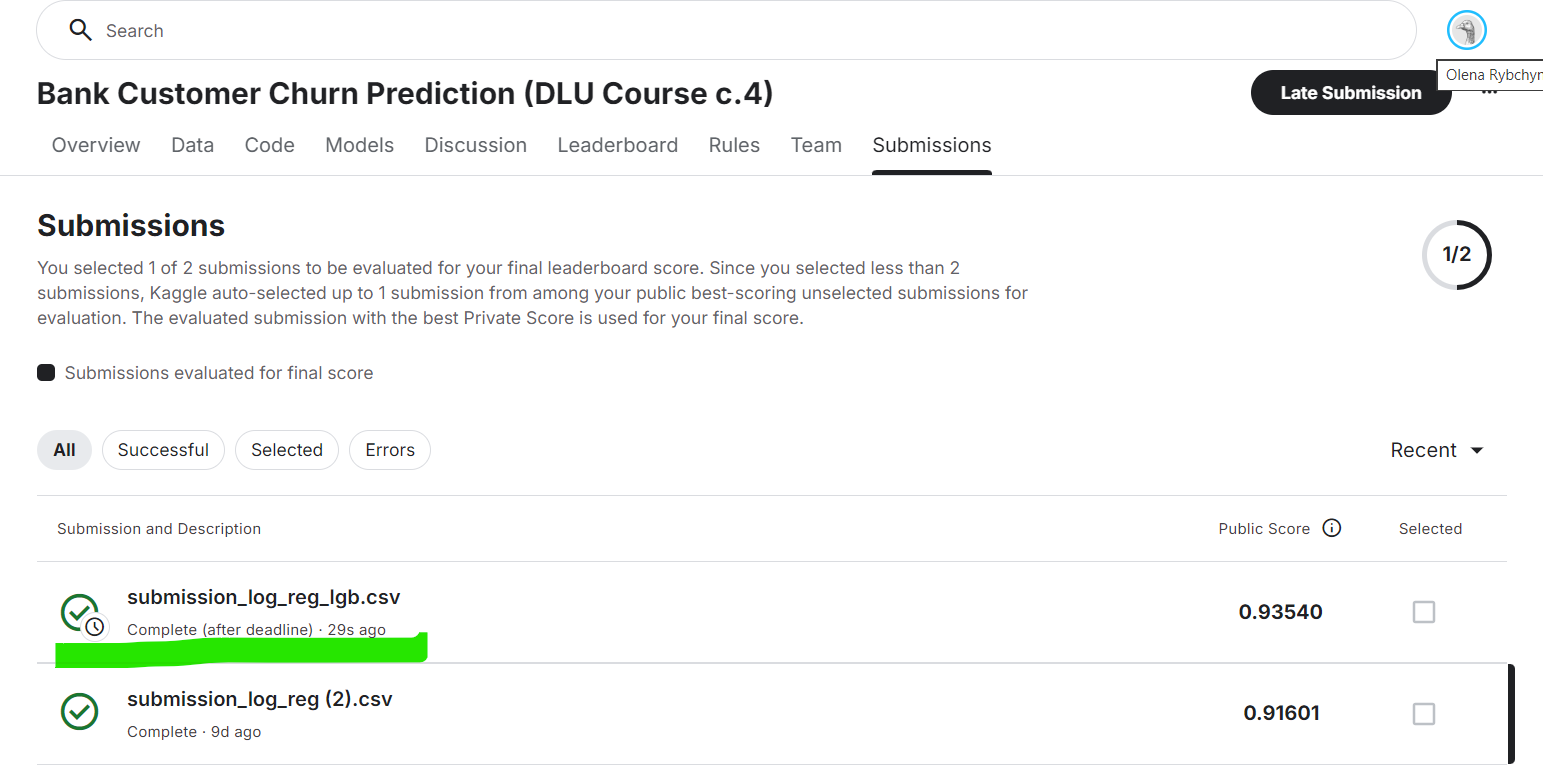